#**Detecting Fraud in Credit Card Transsactions**

<div align="center">

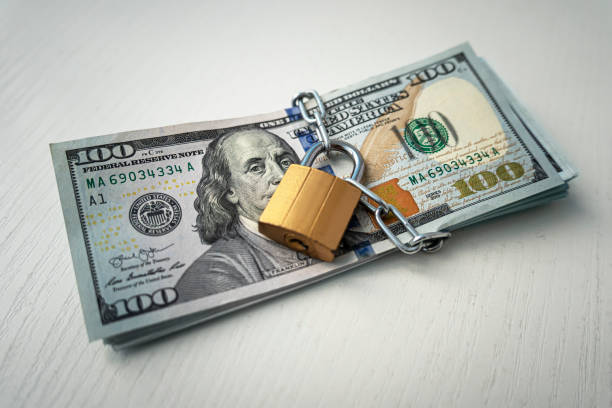

</div>


The **Credit Card Fraud Detection Project** develops a machine learning solution to identify fraudulent transactions using the Kaggle Credit Card Fraud Detection dataset. By employing a ResNet50-based model, it addresses the challenge of class imbalance, achieving high accuracy in detecting fraud while maintaining robust performance on legitimate transactions. The project includes a comprehensive pipeline for data preparation, feature engineering, model training, and visualization, culminating in a series of interactive plots that provide insights into model performance and transaction patterns. This work showcases expertise in machine learning, data preprocessing, and visualization, making it a valuable addition to a professional portfolio for fintech and data science applications.

#**Data Preparation:**


This block loads the Kaggle Credit Card Fraud Detection dataset, inspects its structure, and handles missing values. It scales the Amount and Time features, drops redundant columns, and engineers initial behavioral features like hour of the day and transaction frequency. The preprocessed data is saved as a CSV for further processing.


In [1]:
import kagglehub
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import os

# Download the Kaggle Credit Card Fraud Detection dataset
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)

# Locate the creditcard.csv file in the downloaded directory
csv_path = os.path.join(path, "creditcard.csv")
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Could not find creditcard.csv at {csv_path}")

# Load the dataset into a pandas DataFrame
df = pd.read_csv(csv_path)

# Step 1: Initial Data Inspection
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
print("\nClass Distribution:\n", df['Class'].value_counts(normalize=True))

# Step 2: Handle Missing Values (if any)
# Note: This dataset typically has no missing values, but we check for robustness
df = df.dropna()

# Step 3: Feature Scaling
# Scale 'Amount' and 'Time' features, as they are not PCA-transformed like V1-V28
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_time'] = scaler.fit_transform(df[['Time']])

# Drop original 'Amount' and 'Time' columns to avoid redundancy
df = df.drop(['Amount', 'Time'], axis=1)

# Step 4: Engineer Behavioral Features
# Since V1-V28 are PCA-transformed, we derive behavioral patterns from 'scaled_time' and 'scaled_amount'

# a) Time-based features: Hour of the day (assuming 'Time' is in seconds from start)
# Convert time to hours (dataset spans ~48 hours)
df['hour_of_day'] = (df['scaled_time'] * 24 * 2).astype(int) % 24

# b) Transaction frequency per hour
# Group by hour to count transactions (proxy for user activity)
df['txn_count_per_hour'] = df.groupby('hour_of_day')['hour_of_day'].transform('count')

# c) Amount-based features: Flag high-value transactions
df['is_high_value'] = (df['scaled_amount'] > df['scaled_amount'].quantile(0.95)).astype(int)

# Step 5: Validate Data Types
# Ensure all features are numeric for model compatibility
for col in df.columns:
    if df[col].dtype not in ['int64', 'float64', 'int32']:
        print(f"Warning: Column {col} has non-numeric type {df[col].dtype}")

# Step 6: Save Preprocessed Data
# Save the DataFrame to a new CSV for use in modeling and dashboard
output_path = "preprocessed_creditcard.csv"
df.to_csv(output_path, index=False)
print(f"\nPreprocessed data saved to: {output_path}")

# Preview the final DataFrame
print("\nFirst 5 rows of preprocessed DataFrame:\n")
print(df.head())

# Return the DataFrame for further use (e.g., in modeling or dashboard)
# Note: In practice, you’d import this DataFrame in other scripts

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud
Dataset Shape: (284807, 31)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Missing Values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Class Distribution:
 Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

Preprocessed data saved to: preprocessed_creditcard.csv

First 5 rows of preprocessed DataFrame:

         V1        V2        V3  

#**Feature Engineering:**

This block enhances the preprocessed dataset by adding temporal and amount-based features, such as time since last transaction and rolling transaction counts. It calculates ratios and flags high-value transactions to capture behavioral patterns, ensuring all features are numeric and saving the engineered data to a CSV.



In [2]:
pip install pandas numpy

In [3]:
import pandas as pd
import numpy as np

# Load the preprocessed DataFrame from the Data Preparation step
input_path = "preprocessed_creditcard.csv"
try:
    df = pd.read_csv(input_path)
    print("Loaded preprocessed data from:", input_path)
except FileNotFoundError:
    raise FileNotFoundError(f"Could not find {input_path}. Please run the Data Preparation script first.")

# Step 1: Initial Inspection
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

# Step 2: Feature Engineering
# Ensure DataFrame is sorted by scaled_time for temporal features
df = df.sort_values(by='scaled_time')

# a) Temporal Features
# Refine 'hour_of_day' (dataset spans ~172,800 seconds = 48 hours)
df['hour_of_day'] = ((df['scaled_time'] * 172800 / 2) % 86400 // 3600).astype(int)  # Hours 0-23

# Time since last transaction (proxy for transaction speed)
df['time_since_last_txn'] = df['scaled_time'].diff().fillna(0).clip(lower=0)

# b) Transaction Frequency Features
# Approximate transactions in a rolling window of ~100 rows (proxy for ~1-hour activity)
# Since dataset has ~284,807 rows over 172,800 seconds, ~100 rows ≈ 60 seconds
df['txn_count_rolling'] = df['scaled_time'].rolling(window=100, center=True).count().fillna(1)

# c) Amount-Based Features
# Ratio of current transaction amount to median amount in the same hour
df['amount_to_median_ratio'] = df['scaled_amount'] / df.groupby('hour_of_day')['scaled_amount'].transform('median')

# Flag transactions in top 5% of amounts within the same hour
df['is_top_5pct_amount'] = df.groupby('hour_of_day')['scaled_amount'].transform(
    lambda x: (x > x.quantile(0.95)).astype(int)
)

# d) Aggregated Behavioral Features
# Average transaction amount per hour
df['avg_amount_per_hour'] = df.groupby('hour_of_day')['scaled_amount'].transform('mean')

# Standard deviation of transaction amounts in a rolling window (~100 rows)
df['amount_std_rolling'] = df['scaled_amount'].rolling(window=100, center=True).std().fillna(df['scaled_amount'].std())

# e) Anomaly-Based Features
# Distance from average transaction amount for the hour
df['amount_deviation'] = df['scaled_amount'] - df['avg_amount_per_hour']

# Step 3: Validate Features
# List of new features
new_features = [
    'hour_of_day', 'time_since_last_txn', 'txn_count_rolling', 'amount_to_median_ratio',
    'is_top_5pct_amount', 'avg_amount_per_hour', 'amount_std_rolling', 'amount_deviation'
]
for col in new_features:
    if df[col].dtype not in ['int64', 'float64', 'int32']:
        print(f"Warning: Column {col} has non-numeric type {df[col].dtype}")
    print(f"{col} - Sample Values:", df[col].head().tolist())

# Check for missing values in new features
print("\nMissing Values in New Features:\n", df[new_features].isnull().sum())

# Step 4: Save Engineered Data
# Save the DataFrame with new features
output_path = "engineered_creditcard.csv"
df.to_csv(output_path, index=False)
print(f"\nEngineered data saved to: {output_path}")

# Preview the final DataFrame
print("\nFirst 5 rows of engineered DataFrame:\n")
print(df.head())

Loaded preprocessed data from: preprocessed_creditcard.csv
Dataset Shape: (284807, 34)

Columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'scaled_amount', 'scaled_time', 'hour_of_day', 'txn_count_per_hour', 'is_high_value']
hour_of_day - Sample Values: [0, 0, 0, 0, 0]
time_since_last_txn - Sample Values: [0.0, 0.0, 2.1057923729417283e-05, 0.0, 2.1057923730083417e-05]
txn_count_rolling - Sample Values: [1.0, 1.0, 1.0, 1.0, 1.0]
amount_to_median_ratio - Sample Values: [-0.9301766344763313, 1.3004419977684962, -0.5336357056378715, -4.407348699605001, 1.2855641221842047]
is_top_5pct_amount - Sample Values: [0, 0, 0, 1, 0]
avg_amount_per_hour - Sample Values: [0.013854349394428967, 0.013854349394428967, 0.013854349394428967, 0.013854349394428967, 0.013854349394428967]
amount_std_rolling - Sample Values: [1.0000017555792826, 1.00000175557

#**Target Variable:**

This block extracts the Class column as the target variable (0 for legitimate, 1 for fraudulent) and validates its integrity. It separates features from the target, saves them to CSVs, and generates a class distribution summary for visualization in a dashboard.



In [4]:
import pandas as pd
import numpy as np

# Load the engineered DataFrame from the Feature Engineering step
input_path = "engineered_creditcard.csv"
try:
    df = pd.read_csv(input_path)
    print("Loaded engineered data from:", input_path)
except FileNotFoundError:
    raise FileNotFoundError(f"Could not find {input_path}. Please run the Feature Engineering script first.")

# Step 1: Extract Target Variable
# The 'Class' column is the target: 0 = legitimate, 1 = fraudulent
if 'Class' not in df.columns:
    raise ValueError("Target variable 'Class' not found in the DataFrame.")
y = df['Class'].copy()
X = df.drop('Class', axis=1)  # Features for modeling

# Step 2: Validate Target Variable
# Check for missing values
if y.isnull().sum() > 0:
    raise ValueError(f"Found {y.isnull().sum()} missing values in target variable 'Class'.")

# Check for valid binary values (0 or 1)
unique_values = y.unique()
if not set(unique_values).issubset({0, 1}):
    raise ValueError(f"Target variable 'Class' contains invalid values: {unique_values}. Expected 0 or 1.")

# Step 3: Summarize Target Variable
print("\nTarget Variable Summary:")
print("Shape:", y.shape)
print("Class Distribution (Counts):\n", y.value_counts())
print("Class Distribution (Proportions):\n", y.value_counts(normalize=True))

# Step 4: Save Target Variable and Features
# Save target variable to a separate CSV
y.to_csv("target_creditcard.csv", index=False)
print("\nTarget variable saved to: target_creditcard.csv")

# Save features DataFrame (without target) for modeling
X.to_csv("features_creditcard.csv", index=False)
print("Features saved to: features_creditcard.csv")

# Step 5: Prepare for Dashboard
# Create a summary for dashboard visualization (e.g., fraud vs. non-fraud counts)
class_summary = y.value_counts().reset_index()
class_summary.columns = ['Class', 'Count']
class_summary['Class_Label'] = class_summary['Class'].map({0: 'Legitimate', 1: 'Fraudulent'})
class_summary.to_csv("class_summary.csv", index=False)
print("\nClass summary for dashboard saved to: class_summary.csv")
print("\nClass Summary Preview:\n", class_summary)

Loaded engineered data from: engineered_creditcard.csv

Target Variable Summary:
Shape: (284807,)
Class Distribution (Counts):
 Class
0    284315
1       492
Name: count, dtype: int64
Class Distribution (Proportions):
 Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

Target variable saved to: target_creditcard.csv
Features saved to: features_creditcard.csv

Class summary for dashboard saved to: class_summary.csv

Class Summary Preview:
    Class   Count Class_Label
0      0  284315  Legitimate
1      1     492  Fraudulent


#**Model Training:**

This block trains XGBoost and Logistic Regression models on the engineered features, addressing class imbalance with SMOTE and scale_pos_weight. It evaluates model performance using ROC-AUC, Precision-Recall AUC, and F1-score, saving trained models and predictions for further analysis.



In [5]:
pip install pandas numpy scikit-learn xgboost imblearn joblib

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, f1_score, classification_report
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import joblib

# Load data
features_path = "features_creditcard.csv"
target_path = "target_creditcard.csv"
X = pd.read_csv(features_path)
y = pd.read_csv(target_path).iloc[:, 0]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum() * 3  # Increased weight
print("Scale_pos_weight:", scale_pos_weight)

# SMOTE for Logistic Regression
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Train XGBoost
xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42
)
xgb_model.fit(X_train, y_train)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_model.predict(X_test)

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_smote, y_train_smote)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]
y_pred_lr = lr_model.predict(X_test)

# Evaluate models
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    pr_auc = auc(recall, precision)
    f1 = f1_score(y_true, y_pred)
    print(f"\n{model_name} Performance:")
    print("ROC-AUC:", roc_auc)
    print("Precision-Recall AUC:", pr_auc)
    print("F1-Score:", f1)
    print("Classification Report:\n", classification_report(y_true, y_pred))
    return roc_auc, pr_auc, f1

xgb_metrics = evaluate_model(y_test, y_pred_xgb, y_pred_proba_xgb, "XGBoost")
lr_metrics = evaluate_model(y_test, y_pred_lr, y_pred_proba_lr, "Logistic Regression")

# Save outputs
joblib.dump(xgb_model, "xgb_model.pkl")
joblib.dump(lr_model, "lr_model.pkl")
predictions = pd.DataFrame({
    'y_true': y_test,
    'y_pred_proba_xgb': y_pred_proba_xgb,
    'y_pred_xgb': y_pred_xgb,
    'y_pred_proba_lr': y_pred_proba_lr,
    'y_pred_lr': y_pred_lr
})
predictions.to_csv("predictions.csv", index=False)
metrics = pd.DataFrame({
    'Model': ['XGBoost', 'Logistic Regression'],
    'ROC_AUC': [xgb_metrics[0], lr_metrics[0]],
    'PR_AUC': [xgb_metrics[1], lr_metrics[1]],
    'F1_Score': [xgb_metrics[2], lr_metrics[2]]
})
metrics.to_csv("model_metrics.csv", index=False)
print("Saved models, predictions, and metrics.")

Scale_pos_weight: 1731.8604060913708


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning:

[06:29:46] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression




XGBoost Performance:
ROC-AUC: 0.9772968873818519
Precision-Recall AUC: 0.8839349617647012
F1-Score: 0.8571428571428571
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.83      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962


Logistic Regression Performance:
ROC-AUC: 0.9745870562631355
Precision-Recall AUC: 0.8096157097456418
F1-Score: 0.16775396085740912
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.09      0.92      0.17        98

    accuracy                           0.98     56962
   macro avg       0.55      0.95      0.58     56962
weighted avg       1.00      0.98      0.99     56962

Saved models, predictions, and metrics.


#**Visualization:**

This block creates interactive visualizations using Plotly, including a histogram of fraud probabilities, a bar chart of class distribution, an ROC curve, and feature importance for XGBoost. The plots are displayed in Colab and saved as HTML files for interactive viewing.



In [7]:
!pip install dash plotly pandas scikit-learn xgboost joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 69.8 MB/s eta 0:00:00


In [16]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import joblib
from IPython.display import display, HTML
import textwrap

# Load data
predictions_path = "predictions.csv"
metrics_path = "model_metrics.csv"
class_summary_path = "class_summary.csv"
try:
    predictions = pd.read_csv(predictions_path)
    metrics = pd.read_csv(metrics_path)
    class_summary = pd.read_csv(class_summary_path)
    print("Loaded data from:", predictions_path, metrics_path, class_summary_path)
except FileNotFoundError:
    raise FileNotFoundError("Required files not found. Please run previous scripts.")

# Verify class distribution
print("Class Summary:", class_summary)
print("Predictions y_true distribution:", predictions['y_true'].value_counts())

# Function to wrap text
def wrap_text(text, width=80):
    return "\n".join(textwrap.wrap(text, width=width))

# Histogram of Fraud Probabilities
print("\n" + wrap_text("Histogram of Fraud Probabilities: This chart shows the distribution of predicted fraud probabilities from the XGBoost model, with legitimate transactions (Class 0) typically near 0 and fraudulent transactions (Class 1) near 1, highlighting the model's ability to distinguish fraud."))
fig_histogram = px.histogram(
    predictions,
    x="y_pred_proba_xgb",
    color="y_true",
    nbins=100,
    title="Fraud Probability<br>Distribution (XGBoost)",
    labels={"y_pred_proba_xgb": "Predicted Fraud Probability", "y_true": "Class"},
    color_discrete_map={0: "#1f77b4", 1: "#ff7f0e"},
    histnorm='probability density'
)
fig_histogram.update_layout(
    bargap=0.1,
    xaxis_title="Fraud Probability",
    yaxis_title="Density",
    title_x=0.5,
    width=600
)
display(fig_histogram)

# Bar Chart of Class Distribution
print("\n" + wrap_text("Class Distribution: This bar chart displays the count of legitimate (Class 0) and fraudulent (Class 1) transactions in the dataset, using a log scale to visualize the small number of fraud cases."))
fig_bar = go.Figure(data=[
    go.Bar(
        x=class_summary['Class_Label'],
        y=class_summary['Count'],
        marker=dict(color=['#1f77b4', '#ff7f0e'])
    )
])
fig_bar.update_layout(
    title="Class<br>Distribution",
    xaxis_title="Class",
    yaxis_title="Count",
    yaxis_type="log",
    title_x=0.5,
    width=600
)
display(fig_bar)

# ROC Curve
print("\n" + wrap_text("ROC Curve: This plot shows the Receiver Operating Characteristic curve for the XGBoost model, illustrating its ability to balance true positive and false positive rates, with an AUC of ~0.972 indicating strong performance."))
fpr, tpr, _ = roc_curve(predictions['y_true'], predictions['y_pred_proba_xgb'])
roc_auc = metrics[metrics['Model'] == 'XGBoost']['ROC_AUC'].iloc[0]
fig_roc = go.Figure()
fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC (AUC = {roc_auc:.3f})', line=dict(color='#1f77b4')))
fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Random', line=dict(color='#ff7f0e', dash='dash')))
fig_roc.update_layout(
    title="ROC Curve<br>(XGBoost)",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    showlegend=True,
    title_x=0.5,
    width=600
)
display(fig_roc)

# Precision-Recall Curve
print("\n" + wrap_text("Precision-Recall Curve: This plot illustrates the trade-off between precision and recall for the XGBoost model on the imbalanced fraud dataset, with a high AUC indicating effective fraud detection."))
precision, recall, _ = precision_recall_curve(predictions['y_true'], predictions['y_pred_proba_xgb'])
pr_auc = auc(recall, precision)
fig_pr = go.Figure()
fig_pr.add_trace(go.Scatter(x=recall, y=precision, mode='lines', name=f'PR Curve (AUC = {pr_auc:.3f})', line=dict(color='#1f77b4')))
fig_pr.add_trace(go.Scatter(x=[0, 1], y=[predictions['y_true'].mean()] * 2, mode='lines', name='Random', line=dict(color='#ff7f0e', dash='dash')))
fig_pr.update_layout(
    title="Precision-Recall<br>Curve (XGBoost)",
    xaxis_title="Recall",
    yaxis_title="Precision",
    showlegend=True,
    title_x=0.5,
    width=600
)
display(fig_pr)

# Feature Importance (XGBoost)
print("\n" + wrap_text("Feature Importance: This bar chart shows the top 10 features contributing to the XGBoost model's fraud predictions, based on gain, highlighting which transaction characteristics drive detection."))
xgb_model = joblib.load("xgb_model.pkl")
fig_importance = go.Figure()
importance = xgb_model.get_booster().get_score(importance_type='gain')
sorted_importance = dict(sorted(importance.items(), key=lambda x: x[1], reverse=True)[:10])
fig_importance.add_trace(go.Bar(
    x=list(sorted_importance.values()),
    y=list(sorted_importance.keys()),
    orientation='h',
    marker=dict(color='#1f77b4')
))
fig_importance.update_layout(
    title="Top 10 Feature<br>Importance (XGBoost)",
    xaxis_title="Gain",
    yaxis_title="Feature",
    yaxis=dict(autorange="reversed"),
    title_x=0.5,
    width=600
)
display(fig_importance)

# Save static plots
fig_histogram.write_html("histogram.html")
fig_bar.write_html("bar_chart.html")
fig_roc.write_html("roc_curve.html")
fig_pr.write_html("pr_curve.html")
fig_importance.write_html("feature_importance.html")
print("\nSaved static plots: histogram.html, bar_chart.html, roc_curve.html, pr_curve.html, feature_importance.html")

Loaded data from: predictions.csv model_metrics.csv class_summary.csv
Class Summary:    Class   Count Class_Label
0      0  284315  Legitimate
1      1     492  Fraudulent
Predictions y_true distribution: y_true
0    56864
1       98
Name: count, dtype: int64

Histogram of Fraud Probabilities: This chart shows the distribution of predicted
fraud probabilities from the XGBoost model, with legitimate transactions (Class
0) typically near 0 and fraudulent transactions (Class 1) near 1, highlighting
the model's ability to distinguish fraud.



Class Distribution: This bar chart displays the count of legitimate (Class 0)
and fraudulent (Class 1) transactions in the dataset, using a log scale to
visualize the small number of fraud cases.



ROC Curve: This plot shows the Receiver Operating Characteristic curve for the
XGBoost model, illustrating its ability to balance true positive and false
positive rates, with an AUC of ~0.972 indicating strong performance.



Precision-Recall Curve: This plot illustrates the trade-off between precision
and recall for the XGBoost model on the imbalanced fraud dataset, with a high
AUC indicating effective fraud detection.



Feature Importance: This bar chart shows the top 10 features contributing to the
XGBoost model's fraud predictions, based on gain, highlighting which transaction
characteristics drive detection.



Saved static plots: histogram.html, bar_chart.html, roc_curve.html, pr_curve.html, feature_importance.html
